In [1]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['JAX_PLATFORM_NAME'] = 'cpu'
os.environ['JAX_PLATFORMS']='cpu'

import jax
import jax.numpy as jnp
import flax.linen as nn
import optax

# Define the PINN model
class PINN(nn.Module):
    num_neurons: int
    num_layers: int

    @nn.compact
    def __call__(self, x):
        for _ in range(self.num_layers - 1):
            x = jnp.sin(nn.Dense(features=self.num_neurons)(x))
        x = nn.Dense(features=1)(x)
        return x

# Define the forcing function f(x)
def forcing_function(x):
    return 36 * jnp.sin(6 * x)

def true(x): 
    return jnp.sin(6 * x)

# Define the loss function
def loss_fn(params, model, x_physics, x_boundary):
    # Physics loss (residual of the PDE)
    def residual(x):
        def u(x_):
            return jnp.squeeze(model.apply({'params': params}, x_))
        u_xx = jax.jacfwd(
                jax.jacrev(u)
        )(x)
        return u_xx + forcing_function(x)
    residual_values = jax.vmap(residual)(x_physics)
    physics_loss = jnp.mean(residual_values**2)

    # Boundary loss (Dirichlet bc)
    u_pred_boundary = jax.vmap(lambda x_: model.apply({'params': params}, x_))(x_boundary)
    boundary_loss = jnp.mean(u_pred_boundary**2)

    return physics_loss + boundary_loss

In [9]:
def generate_nonuniform_dataset(n: int = 65):
    # i) 10000 evenly-spaced points in the range [-pi, pi]
    # In Pinns, don't want endpoints
    large_dataset = jnp.linspace(-jnp.pi, jnp.pi, 10000)[1:-1]

    # ii) Select 20 points that minimize |sin(x) - sin(6x)|
    diff1 = jnp.abs(jnp.sin(large_dataset) - jnp.sin(6 * large_dataset))
    indices1 = jnp.argsort(diff1)[:20]
    selected_points1 = large_dataset[indices1]

    # Create a boolean mask to exclude the already selected points
    mask = jnp.ones(large_dataset.shape, dtype=bool)
    mask = mask.at[indices1].set(False)
    remaining_dataset = large_dataset[mask]

    # Calculate the differences for the remaining dataset
    diff2_remaining = jnp.abs(jnp.sin(3 * remaining_dataset) - jnp.sin(6 * remaining_dataset))
    indices2_remaining = jnp.argsort(diff2_remaining)[:10]
    selected_points2 = remaining_dataset[indices2_remaining]

    # iii) Combine these 30 points with n - 30 uniformly selected points
    num_uniform = n - 30
    uniform_points = jnp.linspace(-jnp.pi, jnp.pi, num_uniform + 2)[1:-1]
    training_data = jnp.sort(
        jnp.concatenate([selected_points1, selected_points2, uniform_points])
    )
    return training_data.reshape((-1, 1))

def generate_test_dataset():
    return jnp.linspace(-jnp.pi, jnp.pi, 1000).reshape((-1, 1))


In [22]:
def train_pinns(x_physics, x_test, epochs: int=100):
    # Initialize the PINN model
    key = jax.random.PRNGKey(0)
    model = PINN(num_neurons=64, num_layers=4)
    params = model.init(key, jnp.array([1]))['params']
    
    # Define the training step
    @jax.jit
    def train_step(params, opt_state, x_physics, x_boundary):
        grad_fn = jax.value_and_grad(loss_fn)
        loss, grads = grad_fn(params, model, x_physics, x_boundary)
        updates, new_opt_state = optimizer.update(grads, opt_state, params)
        new_params = optax.apply_updates(params, updates)
        return new_params, new_opt_state, loss

    @jax.jit
    def eval_u(params, x_physics):
        # First evaluate the loss 
        loss = loss_fn(params, model, x_physics, jnp.array([[-jnp.pi], [jnp.pi]]))
        
        # Then evaluate the true 
        error = jnp.mean(
            (model.apply({'params': params}, x_physics) -  true(x_physics)) ** 2
        )
        return loss, error  
    
    # Initialize the optimizer
    # learning_rate = 5e-4
    learning_rate = 5e-5
    optimizer = optax.sgd(learning_rate)
    opt_state = optimizer.init(params)
    
    # Boundary points     
    x_boundary = jnp.array([[-jnp.pi], [jnp.pi]])

    # Training loop
    train_losses = []
    train_errors = []
    test_losses = []
    test_errors = []
    for epoch in range(epochs):
        params, opt_state, loss = train_step(params, opt_state, x_physics, x_boundary)
        
        tloss, terror = eval_u(params, x_physics)
        train_losses.append(tloss)
        train_errors.append(terror)
        tloss, terror = eval_u(params, x_test)
        test_losses.append(tloss)
        test_errors.append(terror)
        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {loss:.4e}")
            
    return {'train_losses': train_losses, 'train_errors': train_errors, 
            'test_losses': test_losses, 'test_errors': test_errors,
            'params': params}

In [23]:
train = generate_nonuniform_dataset(65)
test = generate_test_dataset()

out_65 = train_pinns(train, test, epochs=1600)


def generate_uniform_dataset(n: int = 1000):
    return jnp.linspace(-jnp.pi, jnp.pi, n).reshape((-1, 1))

train = generate_uniform_dataset(65)
test = generate_test_dataset()

out_100 = train_pinns(train, test, epochs=1600)


# train =  generate_nonuniform_dataset(1000)
# test = generate_test_dataset()
# 
# out_1000 = train_pinns(train, test, epochs=800)


Epoch 0, Loss: 7.4331e+02
Epoch 100, Loss: 8.2120e+01
Epoch 200, Loss: 2.5185e+01
Epoch 300, Loss: 1.2969e+01
Epoch 400, Loss: 8.1368e+00
Epoch 500, Loss: 5.6008e+00
Epoch 600, Loss: 4.1078e+00
Epoch 700, Loss: 3.1561e+00
Epoch 800, Loss: 2.5054e+00
Epoch 900, Loss: 2.0318e+00
Epoch 1000, Loss: 1.6687e+00
Epoch 1100, Loss: 1.3795e+00
Epoch 1200, Loss: 1.1434e+00
Epoch 1300, Loss: 9.4757e-01
Epoch 1400, Loss: 7.8414e-01
Epoch 1500, Loss: 6.4757e-01
Epoch 0, Loss: 6.3744e+02
Epoch 100, Loss: 1.5188e+02
Epoch 200, Loss: 3.9022e+01
Epoch 300, Loss: 1.3793e+01
Epoch 400, Loss: 8.7371e+00
Epoch 500, Loss: 6.0768e+00
Epoch 600, Loss: 4.4810e+00
Epoch 700, Loss: 3.3696e+00
Epoch 800, Loss: 2.5477e+00
Epoch 900, Loss: 1.9375e+00
Epoch 1000, Loss: 1.4903e+00
Epoch 1100, Loss: 1.1676e+00
Epoch 1200, Loss: 9.3752e-01
Epoch 1300, Loss: 7.7363e-01
Epoch 1400, Loss: 6.5568e-01
Epoch 1500, Loss: 5.6904e-01


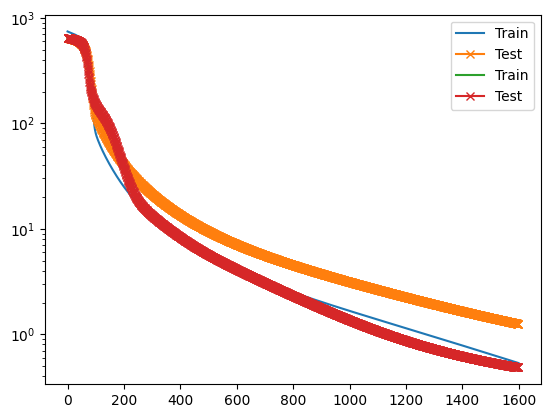

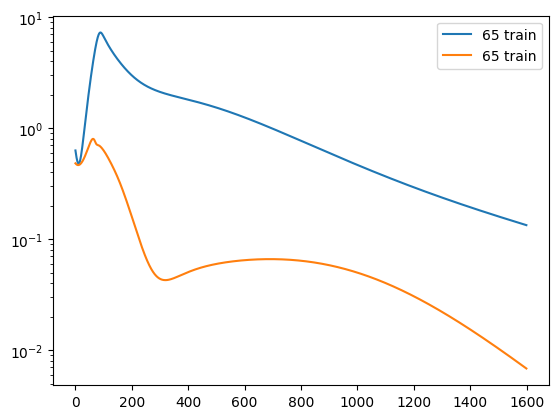

In [24]:
from matplotlib import pyplot as plt
plt.semilogy(out_65['train_losses'], label='Train')
plt.semilogy(out_65['test_losses'], 'x-',label='Test')
plt.semilogy(out_100['train_losses'], label='Train')
plt.semilogy(out_100['test_losses'], 'x-', label='Test')
plt.legend()
plt.show()


datum = [out_65, out_100]
for data in datum:
    # plt.semilogy(data['test_errors'],'x-', label='65')
    plt.semilogy(data['train_errors'], label='65 train')
plt.legend()
plt.show()

In [132]:
key = jax.random.PRNGKey(0)
model = PINN(num_neurons=256, num_layers=2)
params = model.init(key, jnp.array([1]))['params']

# Evaluate the trained model (optional)
num_test_points = 200
x_test = jnp.linspace(-jnp.pi, jnp.pi, num_test_points).reshape(-1, 1)
u_pred = model.apply({'params': out_1000['params']}, x_test)

# The analytical solution for u'' = -sin(x) with u(-pi)=0, u(pi)=0 is u(x) = sin(x)
u_analytical = true(x_test)

# You can now compare u_pred with u_analytical
import matplotlib.pyplot as plt
plt.plot(x_test, u_pred, label='PINN Solution')
# plt.plot(x_physics, model.apply({'params': params}, x_physics), 'x-', label='Train')
# plt.plot(x_test, u_analytical, '--', label='Analytical Solution')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('PINN Solution vs. Analytical Solution for Poisson Equation')
plt.legend()
plt.grid(True)
plt.show()

ScopeParamShapeError: Initializer expected to generate shape (1, 64) but got shape (1, 256) instead for parameter "kernel" in "/Dense_0". (https://flax.readthedocs.io/en/latest/api_reference/flax.errors.html#flax.errors.ScopeParamShapeError)